Step L3: Run after join_liu_greenness and join_greennessx2

NOTE: PLD has better coverage of small gswl lakes

TODO: 
* more clever filter using convex hull: throw out any mismatch based on strict area criteria, then groupby and flag duplicates as currently written
* Rename cols to reflect source ds

In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
import os
import numpy as np
from shapely.geometry import box

from land_cover.load import plot_dir, loadLiu, loadGlobathy, loadGSWL, loadGreenness, GLAKES_gswl_pth

%load_ext autoreload
%autoreload 2

In [2]:
gswl_og = loadGSWL()
gswl = gswl_og

In [3]:
liu = loadGreenness()

In [4]:
gswl.head()

,id_gswl,Zmax_gswl,Zmean_gswl,q_gswl,KG_gswl,LGM_gswl,geometry,area_km2_gswl,dyn_ratio_gswl,depth_ratio_gswl
0,5784180,230.0,48.30,3.76000,26,ice,POINT (35.64414 61.58726),9832.155146,2.052945,0.210000
1,5784179,244.0,86.00,1.84000,26,ice,POINT (-77.76209 43.65539),19384.031984,1.618913,0.352459
2,5784178,1632.0,744.45,1.19000,23,non_ice,POINT (108.19007 53.53539),32101.322845,0.240672,0.456158
3,5784177,84.0,40.00,1.10000,2,non_ice,POINT (32.91142 -1.09922),66865.988181,6.464615,0.476190
4,5784176,1025.0,182.00,4.63187,5,non_ice,POINT (50.84252 41.62349),378000.000000,3.378116,0.177561


In [5]:
gswl.area_km2_gswl.describe()

count    5.784180e+06
mean     4.197405e-01
std      1.697929e+02
min      1.000000e-02
25%      1.695170e-02
50%      3.298882e-02
75%      8.744709e-02
max      3.780000e+05
Name: area_km2_gswl, dtype: float64

In [6]:
liu.head()

,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,mann_kendall_trend,trend_significance,b2_mean,b2_stddev,hylak_count,Dmax_est_PAVEW_m,Dmax_use_m,dyn_ratio_glak_hylak,depth_ratio_globath,geometry
0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-92.00626 46.68239, -92.00653 ..."
1,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,0,...,no sig. trend,0.95,NaN,0.0032,NaN,393.866667,446.000000,2.353112,0.161883,"MULTIPOLYGON (((-119.5765 66.99075, -119.5765 ..."
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,no sig. trend,0.05,NaN,0.0017,NaN,10.764477,10.764477,42.962432,0.353013,"MULTIPOLYGON (((-96.8945 55.40917, -96.89435 5..."
3,11,26827.549399,25926.211686,North America,61.769419,-113.811408,0,1,0,0,...,sig. decreasing,0.01,NaN,0.0016,0.0,6.590199,6.590199,64.406474,0.379351,"MULTIPOLYGON (((-111.128 62.3325, -111.12775 6..."
4,16,17460.818811,16808.357727,Europe,60.829856,31.477989,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((29.8255 61.20653, 29.82523 61...."


In [7]:
# ensure same CRS
if gswl.crs != liu.crs:
    gswl = gswl.to_crs(liu.crs)

# use convex hull for join
# liu["_og_geom"] = liu.geometry
# liu["geometry"] = liu.convex_hull

# spatial join points -> polygons using contains
joined = gpd.sjoin(liu, gswl, how='left', predicate='contains')

In [8]:
grouped = joined.sort_values("Area_bound_glakes").groupby("Lake_id_glakes")
join_counts = grouped.area_km2_gswl.count()
joined = grouped.last()

In [9]:
relative_area_tolerance = 0.05
joined["hylak_count"] = join_counts

# determine matching lakes
joined["match_gswl"] = np.nan

joined.loc[
    joined["area_km2_gswl"] >= 0,
    "match_gswl",
] = 0


valid = joined['area_km2_gswl'].notna() & (joined['Area_PW_glakes'] > 0)
rel_diff = (np.sqrt(joined["area_km2_gswl"]) - np.sqrt(joined["Area_PW_glakes"])).abs() / np.sqrt(joined["Area_PW_glakes"])
joined.loc[
    valid
    & (rel_diff <= relative_area_tolerance )
    # & (joined["Area_bound"] >= joined["area_km2_gswl"])
    & join_counts == 1,
    "match_gswl",
] = 1

print(
    f"Found {len(joined):,} features; liu matches = {joined['match_gswl'].sum():,} / {(~joined.match_gswl.isna()).sum():,}, length of liu: {len(liu):,}"
)

Found 1,878,284 features; liu matches = 71,338.0 / 1,618,748, length of liu: 1,878,284


<Axes: ylabel='Frequency'>

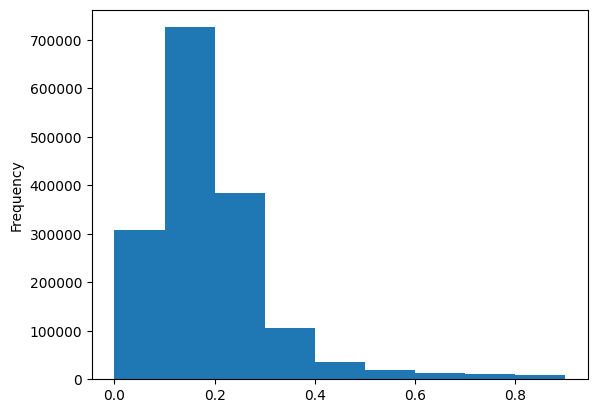

In [10]:
rel_diff.plot.hist(bins=np.arange(0, 1, 0.1))

<Axes: ylabel='Frequency'>

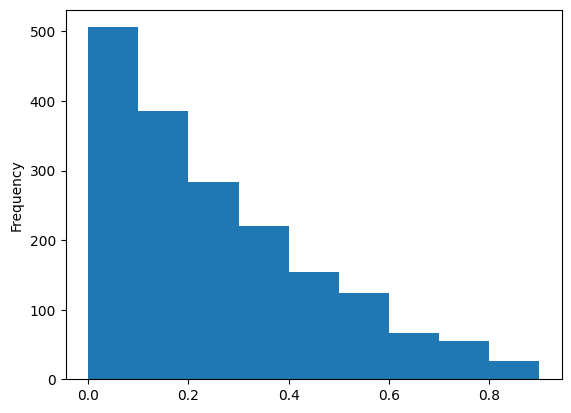

In [11]:
np.log(rel_diff).plot.hist(bins=np.arange(0, 1, 0.1))

Sanity check

<Axes: xlabel='Area_PW_glakes', ylabel='area_km2_gswl'>

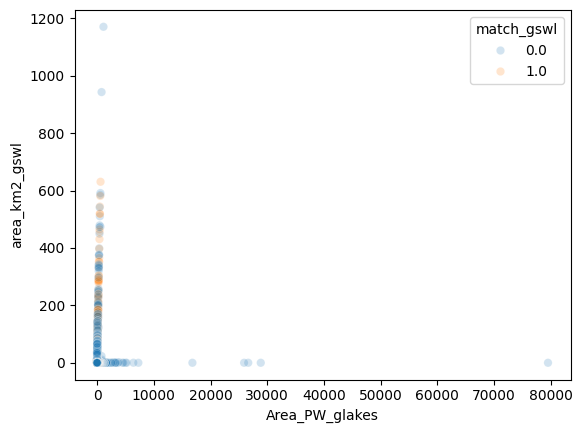

In [12]:
sns.scatterplot(joined, x="Area_PW_glakes", y="area_km2_gswl", hue="match_gswl", alpha=0.2)

(0.0, 3000.0)

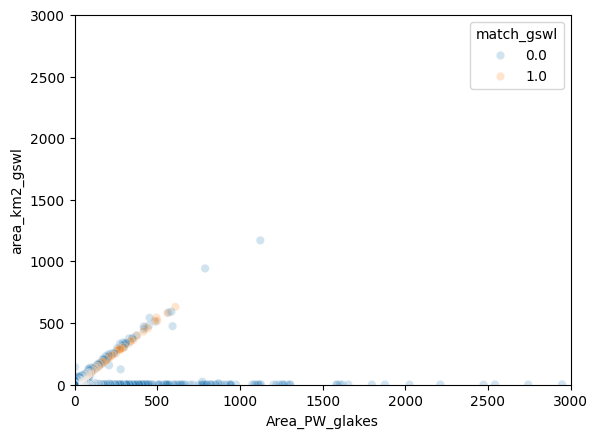

In [31]:
sns.scatterplot(joined, x="Area_PW_glakes", y="area_km2_gswl", hue="match_gswl", alpha=0.2)
plt.xlim([0, 3000])
plt.ylim([0, 3000])

In [13]:
joined.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1878284 entries, 3 to 3426388
Data columns (total 78 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Area_bound_glakes     1878284 non-null  float64 
 1   Area_PW_glakes        1877185 non-null  float64 
 2   Continent_glakes      1878284 non-null  object  
 3   Lat_glakes            1878284 non-null  float64 
 4   Lon_glakes            1878284 non-null  float64 
 5   GFed_flag_glakes      1878284 non-null  int64   
 6   PFed_flag_glakes      1878284 non-null  int64   
 7   Endo_flag_glakes      1878284 non-null  int64   
 8   Rser_flag_glakes      1878284 non-null  int64   
 9   Shape_Leng_glakes     1878284 non-null  float64 
 10  Shape_Area_glakes     1878284 non-null  float64 
 11  areaP1                542298 non-null   float64 
 12  areaP2                542944 non-null   float64 
 13  areaP3                542944 non-null   float64 
 14  NDVI8499       

In [14]:
# convert to pandas nullable integer dtype so values are integers while preserving NA
joined["match_gswl"] = joined["match_gswl"].astype("Int8")

In [15]:
# overwrite
if GLAKES_gswl_pth.exists():
    GLAKES_gswl_pth.unlink()
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=liu.crs)
joined.to_file(GLAKES_gswl_pth)
# joined.loc[joined.match_gswl==True, :].to_file(GLAKES_gswl_pth)

print(
    f"Wrote {len(joined)} features to {GLAKES_gswl_pth}; matches = {joined['match_gswl'].sum()}"
)

Wrote 1878284 features to /Volumes/metis/Datasets/Liu_aq_veg/figshare/v4/25012091/edk_out/GLAKES_gswl.gpkg; matches = 71338
